In [0]:
%sql
CREATE OR REPLACE TABLE workspace.gold.ml_features_bad_review AS
WITH item_main AS (          -- categoría y seller del ítem más caro de la orden
  SELECT s.order_id,
         max_by(p.category, s.price)  AS main_category,
         max_by(s.seller_id, s.price) AS main_seller_id
  FROM workspace.gold.fact_sales s
  JOIN workspace.gold.dim_product p ON s.product_id = p.product_id
  GROUP BY s.order_id
)
SELECT o.order_id,
       o.date_key,
       o.order_value, o.freight_value,
       round(o.freight_value / nullif(o.order_value, 0), 3)        AS freight_ratio,
       o.items_qty, o.sellers_qty, o.max_installments, o.main_payment_type,
       datediff(so.estimated_delivery_ts, so.purchase_ts)          AS promised_days,
       o.delivery_days, o.delivery_delay_days,
       i.main_category,
       cu.state AS customer_state, sl.state AS seller_state,
       CAST(cu.state = sl.state AS INT)                            AS same_state,
       round(2 * 6371 * asin(sqrt(
             pow(sin(radians(sl.lat - gc.lat) / 2), 2) +
             cos(radians(gc.lat)) * cos(radians(sl.lat)) *
             pow(sin(radians(sl.lng - gc.lng) / 2), 2))), 1)       AS distance_km,
       CAST(o.is_bad_review AS INT)                                AS label
FROM workspace.gold.fact_orders o
JOIN workspace.silver.orders so    ON o.order_id = so.order_id
JOIN workspace.silver.customers cu ON so.customer_id = cu.customer_id
LEFT JOIN workspace.silver.geolocation gc ON cu.zip_prefix = gc.zip_prefix
JOIN item_main i                   ON o.order_id = i.order_id
JOIN workspace.gold.dim_seller sl  ON i.main_seller_id = sl.seller_id
WHERE o.order_status = 'delivered'
  AND o.review_score IS NOT NULL
  AND o.delivery_days IS NOT NULL;

num_affected_rows,num_inserted_rows


(95824, 18)
% reviews malas: 12.8%


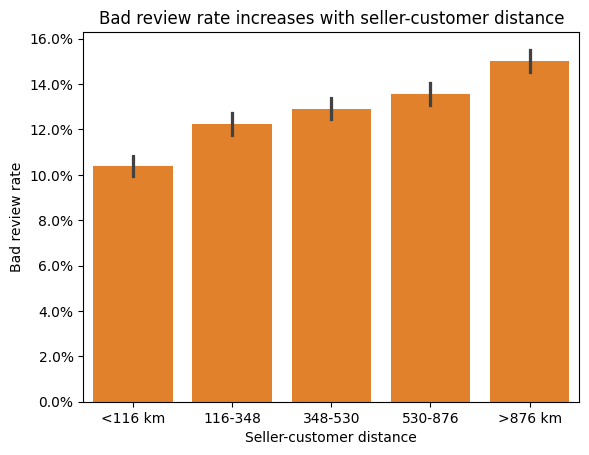

In [0]:
# %pip install seaborn

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = spark.table("workspace.gold.ml_features_bad_review").toPandas()
df["date_key"] = pd.to_datetime(df["date_key"])

print(df.shape)
print(f"% reviews malas: {df['label'].mean():.1%}")

df["distance_bucket"] = pd.qcut(df["distance_km"], 5)
sns.barplot(data=df, x="distance_bucket", y="label")
from matplotlib.ticker import PercentFormatter
labels = ["<116 km", "116-348", "348-530", "530-876", ">876 km"]
ax = sns.barplot(data=df, x="distance_bucket", y="label")
ax.set_xticks(range(len(labels)), labels)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(xlabel="Seller-customer distance", ylabel="Bad review rate",
       title="Bad review rate increases with seller-customer distance")
plt.show()

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["order_value", "freight_value", "freight_ratio", "items_qty", "sellers_qty",
            "max_installments", "promised_days", "delivery_days", "delivery_delay_days",
            "same_state", "distance_km"]
cat_cols = ["main_payment_type", "main_category", "customer_state", "seller_state"]
features = num_cols + cat_cols

cutoff = "2018-05-01"                          # entrenar con el pasado, evaluar con el futuro
train, test = df[df.date_key < cutoff], df[df.date_key >= cutoff]
X_train, y_train = train[features], train["label"]
X_test,  y_test  = test[features],  test["label"]
print(f"train: {len(train):,} | test: {len(test):,}")

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore",
                                            min_frequency=50, sparse_output=False))]), cat_cols),
])

train: 70,582 | test: 25,242


In [0]:
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score

mlflow.sklearn.autolog(log_models=True)

candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "hist_gradient_boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                                             max_iter=300, learning_rate=0.05,
                                                             random_state=42),
}

results = {}
for name, model in candidates.items():
    with mlflow.start_run(run_name=name) as run:
        pipe = Pipeline([("prep", preprocess), ("model", model)])
        pipe.fit(X_train, y_train)

        proba = pipe.predict_proba(X_test)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        metrics = {
            "test_roc_auc":   roc_auc_score(y_test, proba),
            "test_pr_auc":    average_precision_score(y_test, proba),
            "test_recall":    recall_score(y_test, pred),
            "test_precision": precision_score(y_test, pred),
        }
        mlflow.log_metrics(metrics)
        results[name] = {"pipe": pipe, "run_id": run.info.run_id, **metrics}

pd.DataFrame(results).T.drop(columns="pipe")

2026/10/01 13:51:15 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-1931e92340f94c9b9629d85e7bc02beb?o=7474659102524531
2026/10/01 13:51:38 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-c74740f2b3a046538464cc9a4d296872?o=7474659102524531


,run_id,test_roc_auc,test_pr_auc,test_recall,test_precision
logistic_regression,286df1f4b00e4572b8c7d2bf5b605cc5,0.692288,0.258534,0.376634,0.276856
hist_gradient_boosting,70dbfbdf9fda4f548a5682645e250231,0.701353,0.328385,0.42099,0.309642


In [0]:
import numpy as np, pandas as pd, mlflow
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             recall_score, precision_score, precision_recall_curve)
from scipy.stats import loguniform, randint

assert "results" in globals(), "Run cells 2-4 first (Run all above)"

# Sort train by date so CV folds respect time: train on the past, validate on the future
order = train.sort_values("date_key").index
X_tr, y_tr = X_train.loc[order], y_train.loc[order]
tscv = TimeSeriesSplit(n_splits=3)

def evaluate(pipe, threshold=0.5):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {"test_roc_auc":   roc_auc_score(y_test, proba),
            "test_pr_auc":    average_precision_score(y_test, proba),
            "test_recall":    recall_score(y_test, pred),
            "test_precision": precision_score(y_test, pred)}

mlflow.sklearn.autolog(log_models=True, max_tuning_runs=5)

# --- New model: Random Forest ---
with mlflow.start_run(run_name="random_forest") as run:
    rf = Pipeline([("prep", clone(preprocess)),
                   ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                                    max_features="sqrt",
                                                    class_weight="balanced_subsample",
                                                    n_jobs=-1, random_state=42))])
    rf.fit(X_tr, y_tr)
    m = evaluate(rf)
    mlflow.log_metrics(m)
    results["random_forest"] = {"pipe": rf, "run_id": run.info.run_id, **m}

# --- Hyperparameter tuning: HistGradientBoosting, temporal CV, optimizing PR-AUC ---
param_dist = {
    "model__learning_rate":     loguniform(0.02, 0.2),
    "model__max_iter":          randint(200, 800),
    "model__max_leaf_nodes":    randint(15, 64),
    "model__min_samples_leaf":  randint(20, 200),
    "model__l2_regularization": loguniform(1e-3, 10),
}
hgb_base = Pipeline([("prep", clone(preprocess)),
                     ("model", HistGradientBoostingClassifier(class_weight="balanced",
                                                              random_state=42))])
search = RandomizedSearchCV(hgb_base, param_dist, n_iter=20, cv=tscv,
                            scoring="average_precision", n_jobs=-1,
                            random_state=42, refit=True, verbose=1)

with mlflow.start_run(run_name="hgb_tuned") as run:
    search.fit(X_tr, y_tr)
    best_hgb = search.best_estimator_
    m = evaluate(best_hgb)
    mlflow.log_metrics({**m, "cv_pr_auc": search.best_score_})
    results["hgb_tuned"] = {"pipe": best_hgb, "run_id": run.info.run_id, **m}

print("Best CV PR-AUC:", round(search.best_score_, 3))
print("Best params:", search.best_params_)

pd.DataFrame(results).T.drop(columns="pipe").sort_values("test_pr_auc", ascending=False)

2026/10/01 13:52:20 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-5bf8abe4902a4dfaa6be2ebacb26f433?o=7474659102524531


Fitting 3 folds for each of 20 candidates, totalling 60 fits


2026/10/01 13:54:38 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-ba3100562cd04e39badc28cc3ffd7a03?o=7474659102524531
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-7192425ad93b4d438c084bfd777a22de?o=7474659102524531
2026/10/01 13:54:58 INFO mlflow.sklearn.utils: Logging the 5 best runs, 15 runs will be omitted.


Best CV PR-AUC: 0.521
Best params: {'model__l2_regularization': np.float64(0.004207988669606638), 'model__learning_rate': np.float64(0.02864339657822303), 'model__max_iter': 530, 'model__max_leaf_nodes': 25, 'model__min_samples_leaf': 107}


,run_id,test_roc_auc,test_pr_auc,test_recall,test_precision
hist_gradient_boosting,70dbfbdf9fda4f548a5682645e250231,0.701353,0.328385,0.42099,0.309642
hgb_tuned,a16c183d264841d7be026326a2a67a4e,0.706305,0.327741,0.421386,0.309753
random_forest,5cb22ef1593747f1b64539a7e527d705,0.699689,0.318651,0.407525,0.318379
logistic_regression,286df1f4b00e4572b8c7d2bf5b605cc5,0.692288,0.258534,0.376634,0.276856


### Model comparison and tuning
- Three tree-based models (HistGradientBoosting default, tuned, Random Forest) converge at ~0.70 ROC-AUC and ~0.32–0.33 PR-AUC, while logistic regression stays behind (0.26 PR-AUC). The relationship is non-linear, and the current features set the ceiling, not the algorithm.
- Hyperparameter tuning (RandomizedSearchCV, 20 candidates, temporal CV) did not improve test PR-AUC. The default HistGradientBoosting is kept for simplicity.
- Best parameters favor a conservative model (low learning rate, large leaves), consistent with noisy labels.
- CV PR-AUC (0.52) is much higher than test PR-AUC (0.33). The validation folds cover the early-2018 logistics crisis, when bad reviews were mostly delay-driven and easier to predict. This points to a shift in the data over time and the need to monitor and retrain the model.

In [0]:
# Fit on the oldest 80% of train, pick the threshold on the most recent 20%
cut = int(len(X_tr) * 0.8)
val_model = clone(best_hgb).fit(X_tr.iloc[:cut], y_tr.iloc[:cut])
val_proba = val_model.predict_proba(X_tr.iloc[cut:])[:, 1]

prec, rec, thr = precision_recall_curve(y_tr.iloc[cut:], val_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = float(thr[np.argmax(f1[:-1])])
print(f"Threshold that maximizes F1 on validation: {best_thr:.2f}")

pd.DataFrame([evaluate(best_hgb, 0.5), evaluate(best_hgb, best_thr)],
             index=["threshold 0.50", f"threshold {best_thr:.2f}"])

2026/10/01 14:05:42 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9276500e549c43d6825dc28460fdcd14', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 14:05:51 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-1361c070a01340ce9306722321bb7697?o=7474659102524531


Threshold that maximizes F1 on validation: 0.70


,test_roc_auc,test_pr_auc,test_recall,test_precision
threshold 0.50,0.706305,0.327741,0.421386,0.309753
threshold 0.70,0.706305,0.327741,0.290693,0.473243


### Decision threshold
- The threshold that maximizes F1 on validation is 0.70 (chosen on the most recent 20% of train, not on test).
- Raising it from 0.50 to 0.70 trades recall for precision: recall drops from 42% to 29%, while precision rises from 31% to 47%. ROC-AUC and PR-AUC do not change, since the model ranks orders the same way.
- Overall balance is the same (F1 ≈ 0.36 in both cases), so the choice is a business decision. Use 0.50 for cheap automated actions (an email or a small voucher) and 0.70 when each alert triggers a costly manual follow-up.
- At 0.70, almost half of the flagged orders end in a bad review, about 3.5x better than random.

Final model: hist_gradient_boosting


2026/10/01 14:15:01 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c8fbe1da74c44eec98bc765244c5d980', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/01 14:15:08 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-c20e366ea3cb4de5be3a2393f7f55942?o=7474659102524531


Decision threshold (max F1 on validation): 0.69


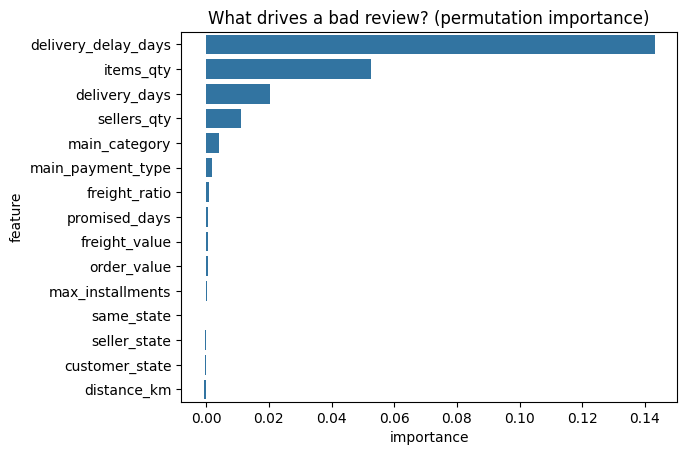

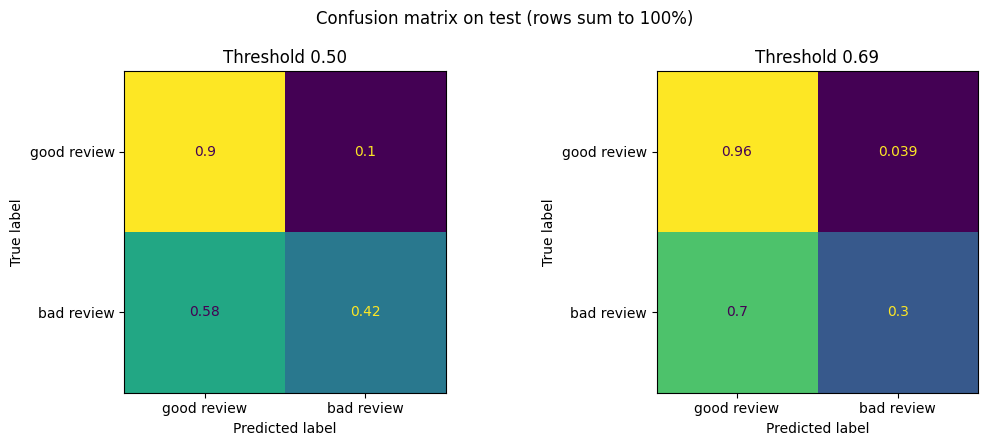

In [0]:
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

missing = [v for v in ["results", "train", "X_train", "y_train", "X_test", "y_test", "features"]
           if v not in globals()]
assert not missing, f"Missing variables {missing}: run the previous cells first (Run all above)"

# 1) Final model: chosen on validation and simplicity, never by looking at test.
#    Tuning did not improve PR-AUC, so we keep the simpler default model.
FINAL_MODEL = "hist_gradient_boosting"
final = results[FINAL_MODEL]["pipe"]
print("Final model:", FINAL_MODEL)

# 2) Decision threshold chosen on validation (most recent 20% of train), not on test
order = train.sort_values("date_key").index
X_tr, y_tr = X_train.loc[order], y_train.loc[order]
cut = int(len(X_tr) * 0.8)
val_proba = (clone(final).fit(X_tr.iloc[:cut], y_tr.iloc[:cut])
                         .predict_proba(X_tr.iloc[cut:])[:, 1])
prec, rec, thr = precision_recall_curve(y_tr.iloc[cut:], val_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
THRESHOLD = float(thr[np.argmax(f1[:-1])])
print(f"Decision threshold (max F1 on validation): {THRESHOLD:.2f}")

# 3) Feature importance on a test sample (faster, same conclusions)
sample = X_test.sample(n=min(8000, len(X_test)), random_state=42)
imp = permutation_importance(final, sample, y_test.loc[sample.index],
                             scoring="average_precision", n_repeats=5, random_state=42)
imp_df = (pd.DataFrame({"feature": features, "importance": imp.importances_mean})
            .sort_values("importance", ascending=False))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("What drives a bad review? (permutation importance)"); plt.show()

# 4) Confusion matrices: default threshold vs business threshold
proba = final.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, t in zip(axes, [0.5, THRESHOLD]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, (proba >= t).astype(int), normalize="true",
        display_labels=["good review", "bad review"], ax=ax, colorbar=False)
    ax.set_title(f"Threshold {t:.2f}")
plt.suptitle("Confusion matrix on test (rows sum to 100%)")
plt.tight_layout(); plt.show()

### Model interpretation

**Model selection**
- The three tree-based models (HistGradientBoosting default, tuned, and Random Forest) converge at ~0.70 ROC-AUC and ~0.32–0.33 PR-AUC, while logistic regression stays behind (0.26 PR-AUC). The relationship is non-linear, and the current features set the ceiling, not the algorithm.
- Hyperparameter tuning (RandomizedSearchCV, 20 candidates, temporal cross-validation) did not improve test PR-AUC, so the simpler default HistGradientBoosting is kept as the final model.
- Cross-validation PR-AUC (0.52) is much higher than test PR-AUC (0.33). The validation folds cover the early-2018 logistics crisis, when bad reviews were mostly delay-driven and easier to predict. The data shifts over time, so a model like this needs monitoring and retraining.

**What drives a bad review?**
- **Delivery delay is by far the strongest driver:** shuffling it drops PR-AUC by ~0.14 (from ~0.33 to ~0.19).
- **Order complexity matters:** orders with more items (`items_qty`) or multiple sellers (`sellers_qty`) are more likely to get a bad review, possibly because they ship in separate packages and arrive incomplete (hypothesis to validate with review comments).
- **Distance adds no information once delivery time is known:** the earlier distance-vs-reviews correlation is explained by longer, less reliable deliveries (correlation ≠ causation).
- **Payment method and installments do not predict satisfaction.**

**Confusion matrix and decision threshold (test set)**
- At the default threshold (0.50), 90% of good reviews are correctly classified (10% false alarms) and 42% of bad reviews are detected, with ~31% precision.
- The threshold that maximizes F1 on validation is ~0.70. Recall drops to ~29%, but precision rises to ~47%: almost half of the flagged orders end in a bad review, about 3.5x better than random.
- Overall balance is the same at both thresholds (F1 ≈ 0.36), so the choice is a business decision: 0.50 for cheap automated actions (an email or a small voucher), 0.70 when each alert triggers a costly manual follow-up.
- The model is best at flagging logistics-driven bad reviews, which the business can act on. The missed ones likely stem from causes not captured in the data (product quality, wrong item).

**Next steps**
- Add seller history features (past bad-review and late-delivery rates, computed only from earlier orders to avoid leakage).
- Monitor performance over time and retrain as logistics conditions change.